# Dataset Exploration: Bank Complaints

This notebook explores the complaint resolution dataset and validates the agent infrastructure.

Run this interactively to:
1. Understand dataset distribution and characteristics
2. Test retrieval baseline quality
3. Validate agent on sample complaints

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

from aieng.agent_evals.complaint_resolution.data_analysis import (
    get_dataset_statistics,
    test_retrieval_on_sample,
    test_agent_on_sample,
    compute_retrieval_metrics,
    compute_agent_metrics,
)
from aieng.agent_evals.complaint_resolution.data import BankComplaintsDataset

print("✓ Imports successful")

✓ Imports successful


## 1. Dataset Overview

In [2]:
# Get statistics
stats, narrative_lengths = get_dataset_statistics(sample_size=1000)

# Display as table
df_stats = pd.DataFrame([
    {
        "Category": s.name,
        "Count": s.count,
        "Percentage": f"{s.percentage:.1f}%",
        "Avg Length": f"{s.avg_narrative_length:.0f}",
        "Min": s.min_narrative_length,
        "Max": s.max_narrative_length,
    }
    for s in stats.values()
])
print(df_stats.to_string(index=False))
print(f"\nTotal dataset size: {sum(s.count for s in stats.values())} complaints")

2026-06-23 10:12:28,653 INFO aieng.agent_evals.complaint_resolution.data.bank_complaints: Downloading bank customer complaints dataset...
2026-06-23 10:12:29,569 INFO aieng.agent_evals.complaint_resolution.data.bank_complaints: Dropped 10 rows with missing/empty narrative or product
2026-06-23 10:12:29,864 INFO aieng.agent_evals.complaint_resolution.data.bank_complaints: Loaded 162411 complaint examples


           Category  Count Percentage Avg Length  Min  Max
        credit_card     78       0.0%         98    1 2412
     retail_banking     80       0.0%         94    1 1777
   credit_reporting    619       0.4%         68    1 2568
mortgages_and_loans    109       0.1%        117    1 2685
    debt_collection    114       0.1%         79    1 2325

Total dataset size: 1000 complaints


## 2. Narrative Distribution

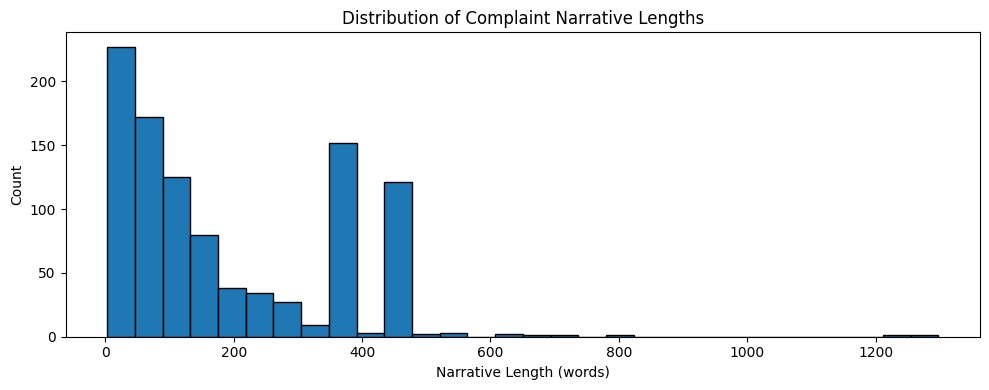

Mean: 191 words
Median: 121 words


In [3]:
# Plot narrative length distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(narrative_lengths, bins=30, edgecolor='black')
ax.set_xlabel('Narrative Length (words)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Complaint Narrative Lengths')
plt.tight_layout()
plt.show()

print(f"Mean: {sum(narrative_lengths)/len(narrative_lengths):.0f} words")
print(f"Median: {sorted(narrative_lengths)[len(narrative_lengths)//2]:.0f} words")

## 3. Sample Complaints

In [4]:
# Show samples from each category
dataset = BankComplaintsDataset()
balanced_samples = dataset.sample_balanced(n_per_category=1, random_state=42)

for example in balanced_samples:
    print(f"\n[{example.category}] (ID: {example.example_id})")
    print(f"Length: {len(example.narrative.split())} words")
    print(f"Text: {example.narrative[:150]}...")
    print("-" * 80)

2026-06-23 10:12:47,242 INFO aieng.agent_evals.complaint_resolution.data.bank_complaints: Downloading bank customer complaints dataset...
2026-06-23 10:12:48,162 INFO aieng.agent_evals.complaint_resolution.data.bank_complaints: Dropped 10 rows with missing/empty narrative or product
2026-06-23 10:12:48,364 INFO aieng.agent_evals.complaint_resolution.data.bank_complaints: Loaded 162411 complaint examples



[credit_card] (ID: 123258)
Length: 99 words
Text: saturday make sevice appointment mother give credit card number company told time may allowed facility covid charge showed immediately pending surpris...
--------------------------------------------------------------------------------

[credit_reporting] (ID: 22851)
Length: 18 words
Text: greeting tried resolve problem credit bureau want investigate case lot error credit report affecting credit score want resolve...
--------------------------------------------------------------------------------

[debt_collection] (ID: 2645)
Length: 17 words
Text: according credit report following portfolio recovery last reported open balance original creditor debt owed reported account stolen...
--------------------------------------------------------------------------------

[mortgages_and_loans] (ID: 588)
Length: 616 words
Text: complaint firstmark answer last complaint firstmark send promissory note loan time asked response send copy letter claimed

## 4. Retrieval Baseline Test

Test if the retrieval tool successfully finds the gold policy document in top-3 results.

In [5]:
# Run retrieval test on 3 per category
retrieval_results = await test_retrieval_on_sample(n_per_category=3, random_state=42)
retrieval_metrics = compute_retrieval_metrics(retrieval_results)

# Display results
df_retrieval = pd.DataFrame([
    {
        "Category": cat,
        "Found": f"{metrics['found_count']}/{metrics['total']}",
        "Precision@3": f"{metrics['precision_at_3']:.1%}",
        "Avg Rank": f"{metrics['avg_rank']:.1f}" if metrics['avg_rank'] else "N/A",
    }
    for cat, metrics in retrieval_metrics.items()
])
print(df_retrieval.to_string(index=False))

ValidationError: 2 validation errors for Configs
OPENAI_API_KEY
  Field required [type=missing, input_value={}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
GEMINI_API_KEY
  Field required [type=missing, input_value={}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

## 5. Agent Smoke Test

Run the agent on one example per category to validate it works.

In [6]:
# Run agent on 1 per category
agent_results = await test_agent_on_sample(n_per_category=1, random_state=42)
agent_metrics = compute_agent_metrics(agent_results)

# Display summary
print(f"Success Rate: {agent_metrics['success_rate']:.1%}")
print(f"Category Accuracy: {agent_metrics['category_accuracy']:.1%}")
print(f"Successful: {agent_metrics['success_count']}/{agent_metrics['total']}")
print()

# Show detailed results
df_agent = pd.DataFrame([
    {
        "Gold Category": r.gold_category,
        "Predicted": r.predicted_category or "ERROR",
        "Match": "✓" if r.gold_category == r.predicted_category else "✗",
        "Status": "OK" if r.success else f"ERROR: {r.error[:30]}",
    }
    for r in agent_results
])
print(df_agent.to_string(index=False))

2026-06-23 10:13:02,076 INFO aieng.agent_evals.complaint_resolution.data.bank_complaints: Downloading bank customer complaints dataset...
2026-06-23 10:13:02,922 INFO aieng.agent_evals.complaint_resolution.data.bank_complaints: Dropped 10 rows with missing/empty narrative or product
2026-06-23 10:13:03,135 INFO aieng.agent_evals.complaint_resolution.data.bank_complaints: Loaded 162411 complaint examples


ValidationError: 2 validation errors for Configs
OPENAI_API_KEY
  Field required [type=missing, input_value={}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing
GEMINI_API_KEY
  Field required [type=missing, input_value={}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.13/v/missing

## Summary

Document key findings for evaluation design:
- Dataset balance (is one category dominant?)
- Narrative complexity (length, preprocessing artifacts)
- Retrieval quality baseline
- Agent readiness (any errors?)